## <font color='blue'>Business Intelligence</font>

### Definição do Problema

***Restaurantes dependem fortemente de gorjetas (tips) como forma de remuneração complementar dos funcionários.***

**O objetivo deste projeto é analisar:**

* quais fatores influenciam o valor da gorjeta
* se o valor da conta impacta proporcionalmente a gorjeta
* se características como:

        tamanho da mesa
        horário
        dia da semana
        fumantes

**Perguntas que vamos responder**
    
* Clientes que gastam mais deixam gorjetas maiores?
* Fumantes dão gorjetas maiores ou menores?
* Mesas maiores deixam mais gorjeta?
* O horário influencia o valor da gorjeta?
* Existe diferença entre homens e mulheres?

## Instalando e Carregando os Pacotes

In [1]:
# Imports

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
dados = pd.read_csv("dados/dataset1.csv")

In [3]:
dados.shape

(244, 7)

In [4]:
dados.dtypes

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

In [5]:
dados.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [6]:
dados.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
dados.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [8]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [9]:
# Variável mais importante

# Percentual de gorjeta.

dados["tip_percent"] = (dados["tip"] / dados["total_bill"]) * 100

**Distribuição das Contas:**

Text(0, 0.5, 'Frequência')

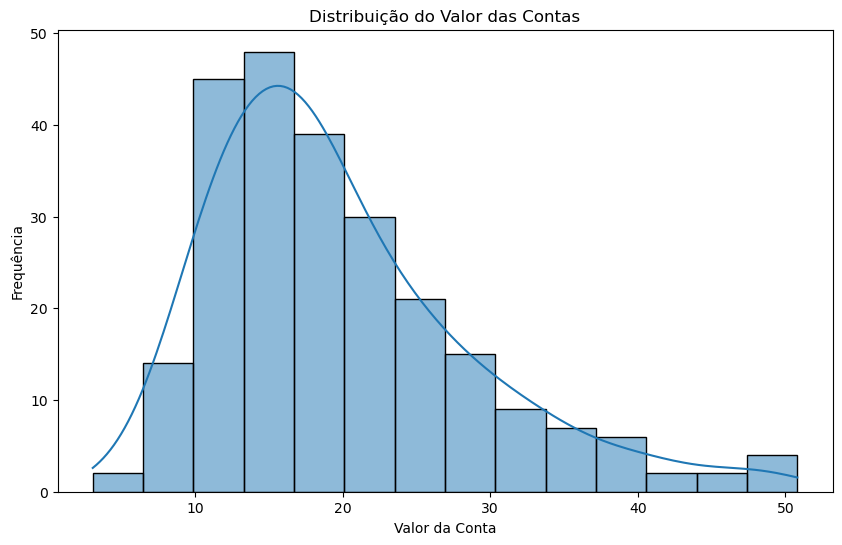

In [10]:
# Distribuição das Contas

plt.figure(figsize=(10,6))
sns.histplot(dados["total_bill"], kde=True)

plt.title("Distribuição do Valor das Contas")
plt.xlabel("Valor da Conta")
plt.ylabel("Frequência")

>A maioria das contas está entre:
>
>10 e 25 dólares
>
>Isso mostra o ticket médio do restaurante.

**Relação Conta vs Gorjeta (com regressão):**

Text(0.5, 1.0, 'Relação entre Valor da Conta e Gorjeta')

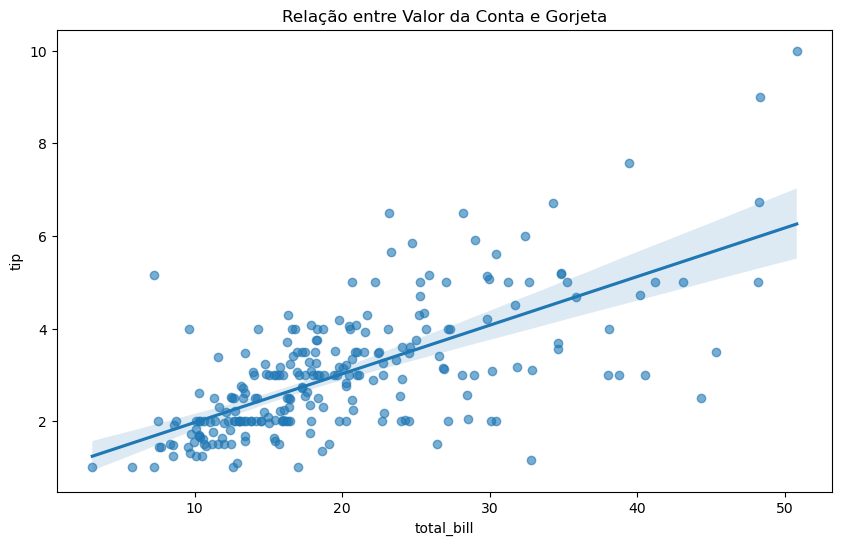

In [11]:
plt.figure(figsize=(10,6))

sns.regplot(
    x="total_bill",
    y="tip",
    data=dados,
    scatter_kws={"alpha":0.6}
)

plt.title("Relação entre Valor da Conta e Gorjeta")

>Existe correlação positiva:
>
>quanto maior a conta → maior a gorjeta.
>
>Mas não proporcional.

**Percentual de Gorjeta por Tamanho da Mesa:**

Text(0.5, 1.0, 'Percentual Médio de Gorjeta por Tamanho da Mesa')

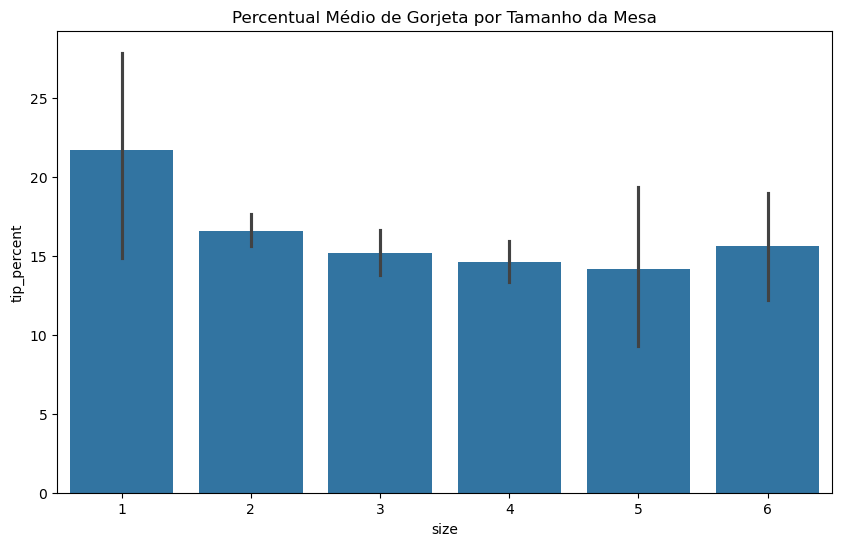

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="size",
    y="tip_percent",
    data=dados
)

plt.title("Percentual Médio de Gorjeta por Tamanho da Mesa")

>Mesas maiores podem:

* pagar mais
* mas dar menor percentual

**Heatmap de Correlação:**

Text(0.5, 1.0, 'Mapa de Correlação das Variáveis')

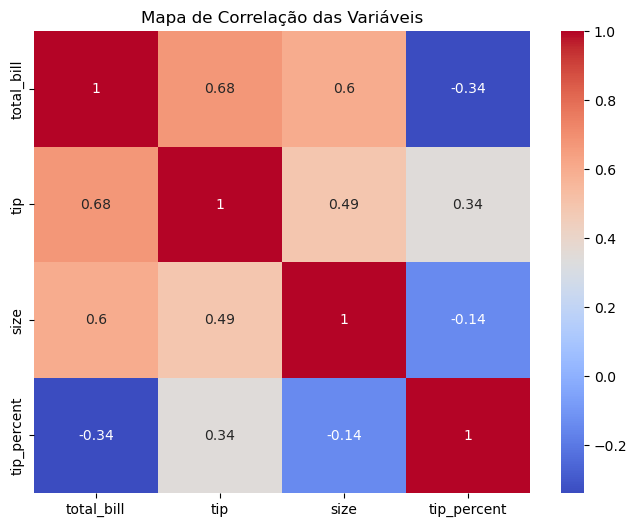

In [13]:
plt.figure(figsize=(8,6))

corr = dados[["total_bill","tip","size","tip_percent"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Mapa de Correlação das Variáveis")

>forte relação entre total_bill e tip
>
>relação moderada com size

**Scatter Plot com a relação entre duas variáveis e os pontos coloridos pelas categorias de uma terceira variável:**
> 
> >Esse gráfico compara valor da conta vs gorjeta, separando os pontos entre fumantes e não fumantes. A partir dele, podemos extrair alguns insights importantes.

<Figure size 2000x800 with 0 Axes>

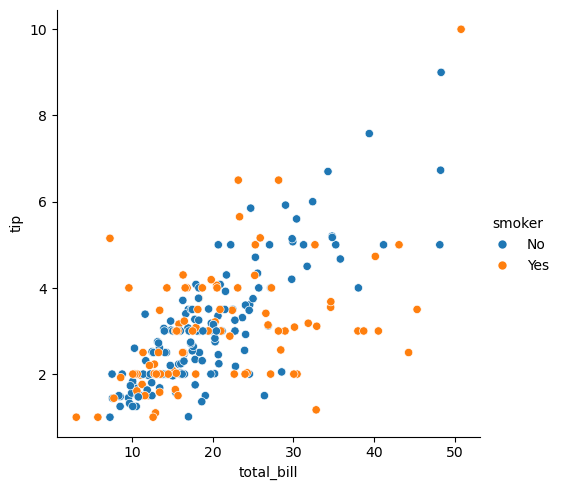

In [14]:
# Dataviz 02
plt.figure(figsize = (20,8))
sns.relplot(x = "total_bill", y = "tip", hue = "smoker", data = dados)

**O gráfico apresenta a relação entre:**

* total_bill → valor total da conta
* tip → gorjeta deixada
* smoker → se o cliente é fumante ou não

>Cada ponto representa uma mesa atendida no restaurante.

**Insight 1 — Relação positiva entre conta e gorjeta**

    Observa-se uma tendência clara de crescimento:
    quanto maior o valor da conta, maior tende a ser a gorjeta.

Isso indica que:

    a gorjeta geralmente acompanha o valor do consumo.
    Isso é esperado, pois muitos clientes deixam gorjetas baseadas em percentual da conta.

**Insight 2 — Não há diferença clara entre fumantes e não fumantes**

    Os pontos de fumantes e não fumantes estão bastante misturados no gráfico.

Isso sugere que:

    O fato de o cliente ser fumante ou não não parece influenciar significativamente o valor da gorjeta.
    Ou seja, o comportamento de gorjeta é semelhante entre os dois grupos.

**Insight 3 — Contas maiores concentram maior variação de gorjetas**

Para contas pequenas:

    as gorjetas ficam geralmente entre 1 e 3 dólares

Para contas maiores:

    há uma variação maior de gorjetas
    Isso pode indicar que clientes com contas mais altas:
    têm maior liberdade para decidir a gorjeta
    não seguem sempre um percentual fixo.

***Para o restaurante:***

1. o valor da conta é o principal fator associado à gorjeta
2. o perfil fumante ou não fumante não altera significativamente o comportamento de gorjeta

**Dataviz 03 - Scatter Plot com a relação entre duas variáveis, os pontos coloridos pelas categorias de uma terceira variável e diferentes símbolos por categoria (gráfico mostrando informação de 3 variáveis diferentes):**

Esse gráfico adiciona uma segunda forma de diferenciação visual (cor + formato do marcador) para a variável smoker, permitindo identificar mais facilmente os dois grupos.

<Figure size 2000x800 with 0 Axes>

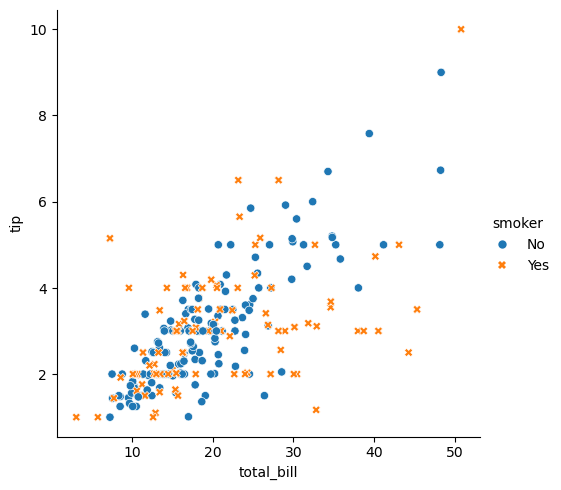

In [15]:
# Dataviz 03
plt.figure(figsize = (20,8))
sns.relplot(x = "total_bill", y = "tip", hue = "smoker", style = "smoker", data = dados)

**Dataviz 04 - Scatter Plot com a relação entre duas variáveis, os pontos coloridos pelas categorias de uma terceira variável, diferentes símbolos por categoria e por variável (gráfico mostrando informação de 4 variáveis diferentes):**

Nesse gráfico começamos a analisar quatro variáveis ao mesmo tempo, o que torna a visualização mais rica para entender o comportamento dos clientes.

<Figure size 2000x800 with 0 Axes>

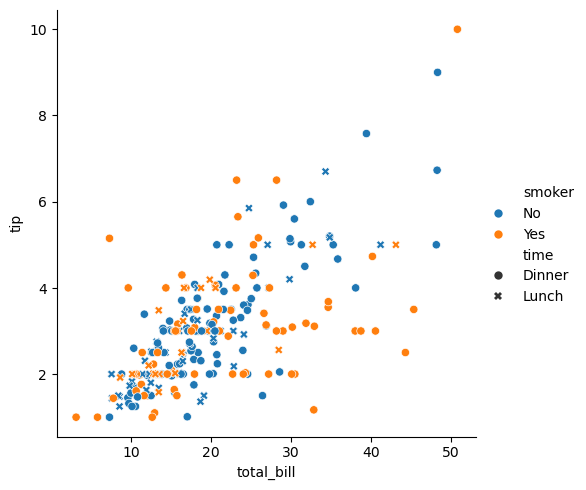

In [16]:
# Dataviz 04
plt.figure(figsize = (20,8))
sns.relplot(x = "total_bill", y = "tip", hue = "smoker", style = "time", data = dados)

>O gráfico mostra simultaneamente:

* total_bill → valor total da conta
* tip → valor da gorjeta
* smoker → cor dos pontos (fumante ou não fumante)
* time → formato dos pontos (almoço ou jantar)

>Cada ponto representa uma mesa atendida no restaurante.

**Insight 1 — Relação positiva entre conta e gorjeta**

Observa-se novamente uma tendência clara de crescimento:

    Quanto maior o valor da conta, maior tende a ser a gorjeta.

    Esse padrão aparece independentemente do horário ou do hábito de fumar.

    Isso sugere que o principal fator associado à gorjeta é o valor da conta.

**Insight 2 — Contas maiores aparecem com mais frequência no jantar**

    Ao observar os marcadores referentes ao Dinner, nota-se que:
    Muitas das contas mais altas aparecem nesse período

Isso sugere que:

    o jantar tende a gerar contas maiores que o almoço.

* Possíveis motivos:
    
        refeições mais completas
        consumo de bebidas
        encontros sociais mais longos.

**Dataviz 05 - Scatter Plot com a relação entre duas variáveis e os pontos coloridos pelas categorias de uma terceira variável (gráfico mostrando informação de 3 variáveis diferentes):**

In [17]:
dados.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


<Figure size 2000x800 with 0 Axes>

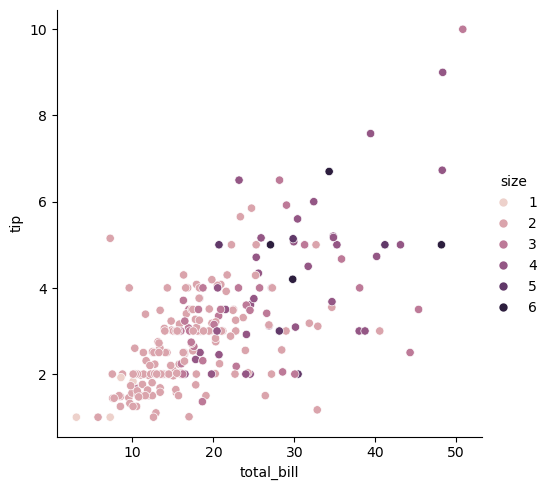

In [18]:
# Dataviz 05
plt.figure(figsize = (20,8))
sns.relplot(x = "total_bill", y = "tip", hue = "size", data = dados)

**Insight 1 — Relação entre tamanho da mesa e valor da conta**

    Observa-se que mesas maiores (valores maiores de size) tendem a aparecer em contas mais altas.

Isso é esperado, pois:

    quanto maior o número de pessoas na mesa, maior tende a ser o consumo total.

**Insight 2 — Mesas maiores tendem a gerar gorjetas maiores**

    Mesas com mais pessoas geralmente apresentam gorjetas mais altas em valor absoluto.

Isso ocorre porque:

    contas maiores naturalmente levam a gorjetas maiores
    muitas vezes o valor da gorjeta é dividido entre os clientes.

**Insight 3 — Mesas pequenas são mais frequentes**

Observa-se que a maior parte dos pontos corresponde a:***mesas de 2 ou 3 pessoas***

Isso sugere que:

    a maior parte do movimento do restaurante é formada por pequenos grupos.

    Esse tipo de informação pode ajudar o restaurante a planejar melhor a disposição das mesas.

**Insight 4 — Mesas grandes são mais raras**

***Mesas com 5 ou 6 pessoas aparecem com menos frequência no gráfico.***

Isso indica que:

    grupos grandes são menos comuns
    mas quando aparecem geram contas e gorjetas maiores.

**Para o restaurante, isso sugere que:**

    O fluxo principal de clientes é composto por pequenos grupos
    mesas maiores geram maior faturamento por atendimento
    estratégias de acomodação podem considerar essa distribuição.

>Por exemplo:

    priorizar mesas para 2–4 pessoas
    mas manter algumas mesas maiores para grupos.

**Dataviz 08 - Scatter Plot com a relação entre duas variáveis e os pontos com tamanhos definidos pelas categorias de uma terceira variável, com ajuste da escala dos símbolos (gráfico mostrando informação de 3 variáveis diferentes):**

Neste gráfico mudamos a forma de representar a variável size: em vez de cores, utilizamos variação de tamanho entre os pontos; o tamanho dos pontos representa o número de pessoas na mesa. Isso facilita perceber como grupos maiores influenciam consumo e gorjeta.

<Figure size 2000x800 with 0 Axes>

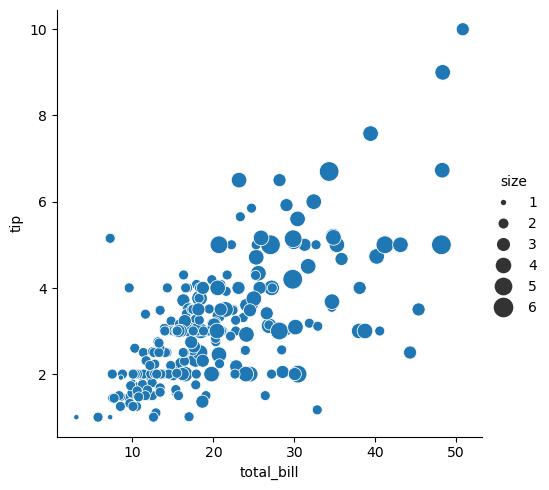

In [19]:
# Dataviz 08
plt.figure(figsize = (20,8))
sns.relplot(x = "total_bill", y = "tip", size = "size", sizes = (15, 200), data = dados)

### Conclusão do Projeto

A análise mostrou que o valor da conta é o principal fator que influencia o valor da gorjeta. No entanto, o percentual de gorjeta não cresce proporcionalmente ao valor da conta, indicando um possível comportamento psicológico dos clientes. Mesas maiores tendem a gerar gorjetas totais maiores, mas com percentual menor. Esses resultados podem ajudar restaurantes a entender melhor o comportamento de seus clientes e otimizar estratégias de atendimento e divisão de gorjetas.

# Fim